# Tester la face recognition*

## Importer les modules

In [142]:
import torch
import mediapipe as mp
import cv2
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Image
import ipywidgets as widgets
import threading

print("CUDA Available:", torch.cuda.is_available())
print("CUDA Device Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")
print("Mediapipe Version:", mp.__version__)
print("OpenCV Version:", cv2.__version__)

CUDA Available: True
CUDA Device Name: NVIDIA GeForce RTX 3060
Mediapipe Version: 0.10.21
OpenCV Version: 4.11.0


In [143]:
import kagglehub
import os

root_data_path = kagglehub.dataset_download("ziya07/depvidmood-facial-expression-video-dataset")
print("Path to dataset files:", root_data_path)

Path to dataset files: /home/thomas/.cache/kagglehub/datasets/ziya07/depvidmood-facial-expression-video-dataset/versions/1


## Le Code

On va ouvrir une image et afficher les points dans l'espace d'un visage.

In [144]:
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh()
mp_pose = mp.solutions.pose
pose = mp_pose.Pose()

def find_angle(x1, y1, x2, y2):
    v = np.array([x2 - x1, y2 - y1])
    w = np.array([0, -1])
    cos_theta = np.dot(v, w) / (np.linalg.norm(v) * np.linalg.norm(w))
    angle_rad = np.arccos(cos_theta)
    return np.degrees(angle_rad)

def find_distance(x1, y1, x2, y2):
    return np.linalg.norm(np.array([x2 - x1, y2 - y1]))

def render_pt_mesh(result, img, pt_color = (0, 255, 0), pt_size = 1):
    for lm in result.landmark:
        h, w, _ = img.shape
        x, y = int(lm.x * w), int(lm.y * h)
        cv2.circle(img, (x, y), pt_size, pt_color, -1)

W0000 00:00:1754076854.752793   23822 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


W0000 00:00:1754076854.762948   23822 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [ ]:
def calculate_pos(l_shldr, r_shldr, nose):
    l_shldr_x, l_shldr_y = l_shldr
    r_shldr_x, r_shldr_y = r_shldr
    l_nose_x, l_nose_y = nose

    # Calculate the midpoint between shoulders
    mid_shldr_x = int((l_shldr_x + r_shldr_x) / 2)
    mid_shldr_y = int((l_shldr_y + r_shldr_y) / 2)

    # Vector from midpoint of shoulders to nose
    nose_to_mid_dx = l_nose_x - mid_shldr_x
    nose_to_mid_dy = l_nose_y - mid_shldr_y

    # Calculate neck rotation angle (0 = straight, negative = left, positive = right)
    neck_angle = np.degrees(np.arctan2(nose_to_mid_dx, -nose_to_mid_dy))

    # Display the angles on the image
    print(f'Neck rot: {neck_angle:.1f} deg')

def get_pos_info(img, pose_result):
    h, w, _ = img.shape
    lmPose = mp_pose.PoseLandmark
    lm = pose_result.pose_landmarks

    l_shldr = (
        int(lm.landmark[lmPose.LEFT_SHOULDER].x * w),
        int(lm.landmark[lmPose.LEFT_SHOULDER].y * h)
    )
    r_shldr = (
        int(lm.landmark[lmPose.RIGHT_SHOULDER].x * w),
        int(lm.landmark[lmPose.RIGHT_SHOULDER].y * h)
    )
    nose = (
        int(lm.landmark[lmPose.NOSE].x * w),
        int(lm.landmark[lmPose.NOSE].y * h)
    )
    return l_shldr, r_shldr, nose

def render_pos(img, l_shldr, r_shldr, nose, pt_size = 2):
    # l_shldr_x, l_shldr_y = l_shldr
    # r_shldr_x, r_shldr_y = r_shldr
    # l_nose_x, l_nose_y = nose

    # ft_scale = 0.5
    cv2.circle(img, l_shldr, pt_size, (255, 0, 0), -1)
    # cv2.putText(img, 'Left Shoulder', (l_shldr_x + 10, l_shldr_y), cv2.FONT_HERSHEY_SIMPLEX, ft_scale, (255, 0, 0), 2)

    cv2.circle(img, r_shldr, pt_size, (0, 255, 0), -1)
    # cv2.putText(img, 'Right Shoulder', (r_shldr_x + 10, r_shldr_y), cv2.FONT_HERSHEY_SIMPLEX, ft_scale, (0, 255, 0), 2)

    cv2.circle(img, nose, pt_size, (0, 0, 255), -1)
    # cv2.putText(img, 'Nose', (l_nose_x + 10, l_nose_y), cv2.FONT_HERSHEY_SIMPLEX, ft_scale, (0, 0, 255), 2)

### La première image

En couleur maintenant

Neck rot: 4.2 deg


W0000 00:00:1754076854.816397   23834 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1754076854.851292   23834 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


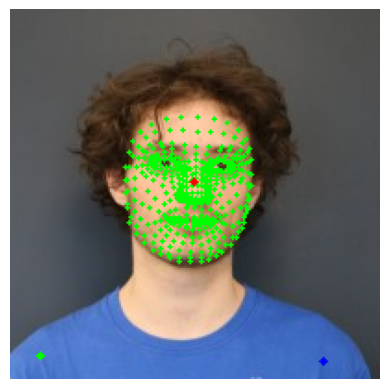

In [146]:
img = cv2.imread("images/mvr.jpg")

result = face_mesh.process(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
pose_result = pose.process(img)

if result.multi_face_landmarks:
    for landmarks in result.multi_face_landmarks:
        render_pt_mesh(landmarks, img)

if pose_result.pose_landmarks:
    l_shldr, r_shldr, nose = get_pos_info(img, pose_result)
    render_pos(img, l_shldr, r_shldr, nose)
    calculate_pos(l_shldr, r_shldr, nose)

plt.axis('off')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

### Second image

White and black images test

Neck rot: -0.8 deg


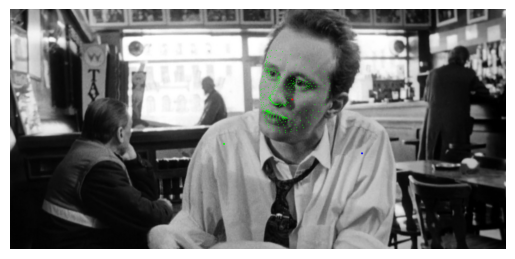

In [148]:
img_black_white = cv2.imread("images/noiretblanc.png")

result = face_mesh.process(cv2.cvtColor(img_black_white, cv2.COLOR_BGR2RGB))

pose_result = pose.process(img_black_white)

if result.multi_face_landmarks:
    for landmarks in result.multi_face_landmarks:
        render_pt_mesh(landmarks, img_black_white)
else:
    print("No face landmarks found in the image.")

if pose_result.pose_landmarks:
    l_shldr, r_shldr, nose = get_pos_info(img_black_white, pose_result)
    render_pos(img_black_white, l_shldr, r_shldr, nose, 3)
    calculate_pos(l_shldr, r_shldr, nose)
else:
    print("No pose landmarks found in the image.")

plt.axis('off')
plt.imshow(cv2.cvtColor(img_black_white, cv2.COLOR_BGR2RGB))
plt.show()


### Video

on va utiliser une vidéo pour détecter les points dans l'espace

In [152]:
import time

actor_data_path = os.path.join(root_data_path, "Data/Video_Dataset/Video_Dataset/Video_Speech_Actor_06/Actor_06")
video_path = os.path.join(actor_data_path, "01-01-02-01-02-02-06.mp4")

cap = cv2.VideoCapture(video_path)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    result = face_mesh.process(rgb_frame)
    pose_result = pose.process(rgb_frame)

    if result.multi_face_landmarks:
        for face_landmarks in result.multi_face_landmarks:
            render_pt_mesh(face_landmarks, frame, pt_size=1)

    # IL Y A UN petit soucis, les épaules sont invisibles
    if pose_result.pose_landmarks:
        l_shldr, r_shldr, nose = get_pos_info(frame, pose_result)
        render_pos(frame, l_shldr, r_shldr, nose, 3)
        # calculate_pos(l_shldr, r_shldr, nose)
    else:
        print("No pose landmarks found in the image.")

    cv2.imshow('Video', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
    time.sleep(0.05) # slows down frames

print("Video finished")
cap.release()
cv2.destroyAllWindows()

Video finished


### Webcam

et si on utilisait une webcam 😳

In [ ]:
stop_btn = widgets.ToggleButton(
    value=False,
    description='Stop',
    disabled=False,
    button_style='danger', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='Description',
    icon='square' # (FontAwesome names without the `fa-` prefix)
)


def view(button):
    cap = cv2.VideoCapture(0)
    display_handle=display(None, display_id=True)
    i = 0
    while True:
        _, frame = cap.read()
        frame = cv2.flip(frame, 1) # if your camera reverses your image
        _, frame = cv2.imencode('.jpeg', frame)
        display_handle.update(Image(data=frame.tobytes()))
        if stop_btn.value==True:
            cap.release()
            display_handle.update(None)


display(stop_btn)
thread = threading.Thread(target=view, args=(stop_btn,))
thread.start()

Shutdown

In [ ]:
face_mesh.close()